XGboost

In [3]:
import datetime
import pandas as pd
import joblib

import sys, os

added_path = os.path.abspath("..")
sys.path.append(added_path)

# utils 모듈 임포트
from utils.naver_searchad_relkeyword import fetch_relkwdstat
from utils.naver_shoppinginsite_search import fetch_category_keyword_data

if added_path in sys.path:
    sys.path.remove(added_path)

# ===== 상수 선언 =====
KEYWORD = "비비고 육개장"
DISCOUNT_PRICE = 2000
PRICE_FACTORS = [0.6, 0.8, 1.0, 1.2, 1.4]
GOOD_ID = "11508428"
CATEGORY_CODE = "50000006"

# ===== 모델 불러오기 =====
xgb_package = joblib.load("../models/xgb_model.pkl")
xgb = xgb_package["model"]
X_columns = xgb_package["columns"]
goodid_encoder = xgb_package["goodid_encoder"]

# ===== 최근 클릭수 비율 계산 =====
rel_data = fetch_relkwdstat([KEYWORD])
recent_avg = rel_data[0].get("최근4주클릭수평균", 0) if rel_data else 0

today = pd.Timestamp.today()
start_date, end_date = today - pd.DateOffset(days=30), today

try:
    search_df = fetch_category_keyword_data(
        start_date=start_date.strftime("%Y-%m-%d"),
        end_date=end_date.strftime("%Y-%m-%d"),
        category=CATEGORY_CODE,
        keyword=KEYWORD
    )
except Exception as e:
    print(f"⚠️ API 호출 실패: {e}")
    search_df = pd.DataFrame(columns=["날짜","클릭량"])

prev_sum = search_df["클릭량"].sum() if not search_df.empty else 0
total_clicks = recent_avg * 30
recent_ratio = (total_clicks / prev_sum) if prev_sum > 0 else 0

# ===== 예측 데이터 생성 및 수행 =====
rows = []
dates = []

for day_offset in range(0, 7):  # 오늘 포함 7일
    target_date = datetime.date.today() + datetime.timedelta(days=day_offset)
    weekday = pd.Timestamp(target_date).weekday()  # 0=월, 6=일
    dates.append(target_date.strftime("%Y-%m-%d"))

    row = []
    for factor in PRICE_FACTORS:
        price = int(DISCOUNT_PRICE * factor)

        # good_id 문자열을 인코더로 숫자 변환
        good_id_enc = goodid_encoder.transform([GOOD_ID])[0]

        test_data = {
            "discount_price": price,
            "최근4주클릭수_비율": recent_ratio,
            "weekday": weekday,
            "good_id_enc": good_id_enc
        }
        test_df = pd.DataFrame([test_data])
        test_df = test_df.reindex(columns=X_columns, fill_value=0)

        # XGBoost 예측 (numpy.float32 → float 변환)
        pred_clicks = float(max(0, xgb.predict(test_df)[0]))
        row.append(pred_clicks)
    rows.append(row)

# ===== 결과를 DataFrame으로 정리 =====
result_df = pd.DataFrame(rows, index=dates, columns=[f"{int(f*100)}%" for f in PRICE_FACTORS])
print(result_df)

                  60%        80%       100%       120%       140%
2026-04-16  52.751610  57.109337  54.129475  10.902122  15.076410
2026-04-17  43.641998  60.429203  57.449337  10.184752  14.359048
2026-04-18  36.688583  55.050179  52.070312   9.381167  12.794482
2026-04-19  38.298367  57.238270  54.258404  11.014561  13.896735
2026-04-20  46.129898  60.694019  58.387074  14.624144  14.947798
2026-04-21  45.696499  62.853504  60.453278  15.255631  15.808729
2026-04-22  47.880955  56.881969  53.902100  11.405577  13.085635


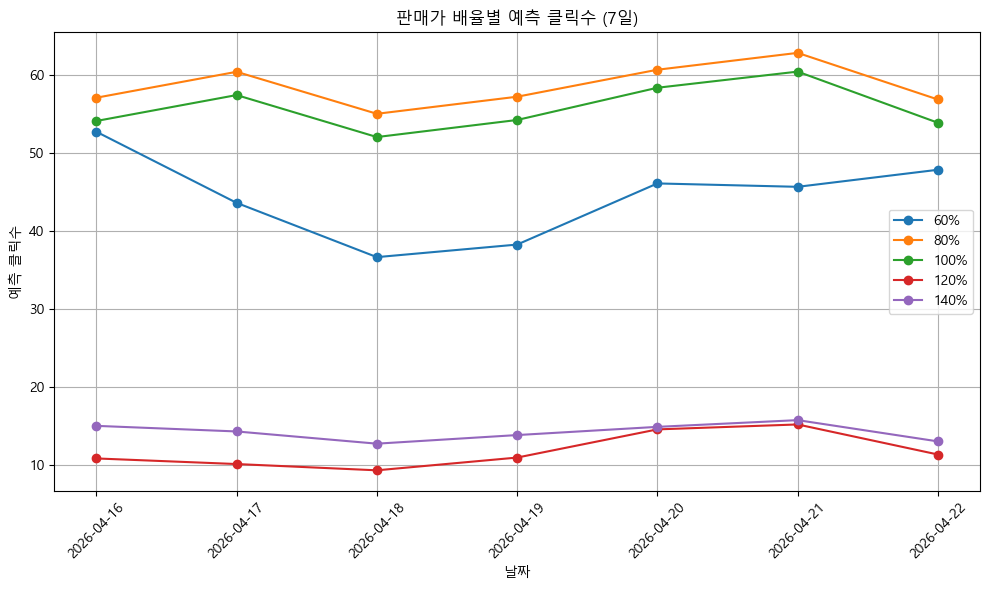

gam

In [6]:
import datetime
import pandas as pd
import joblib

import sys, os

added_path = os.path.abspath("..")
sys.path.append(added_path)

# utils 모듈 임포트
from utils.naver_searchad_relkeyword import fetch_relkwdstat
from utils.naver_shoppinginsite_search import fetch_category_keyword_data

if added_path in sys.path:
    sys.path.remove(added_path)


# ===== 상수 선언 =====
KEYWORD = "비비고 육개장"
DISCOUNT_PRICE = 2000
PRICE_FACTORS = [0.6, 0.8, 1.0, 1.2, 1.4]
GOOD_ID = "11508428"
CATEGORY_CODE = "50000006"

# ===== 모델 불러오기 =====
gam_package = joblib.load("../models/gam_model.pkl")
gam = gam_package["model"]
X_columns = gam_package["columns"]
goodid_encoder = gam_package["goodid_encoder"]  # 학습 때 저장한 인코더 불러오기

# ===== 예측 데이터 생성 및 수행 =====
rows = []
dates = []

for day_offset in range(0, 7):  # 오늘 포함 7일
    target_date = datetime.date.today() + datetime.timedelta(days=day_offset)
    weekday = pd.Timestamp(target_date).weekday()  # 0=월, 6=일
    dates.append(target_date.strftime("%Y-%m-%d"))

    row = []
    for factor in PRICE_FACTORS:
        price = int(DISCOUNT_PRICE * factor)

        # good_id 문자열을 인코더로 숫자 변환
        good_id_enc = goodid_encoder.transform([GOOD_ID])[0]

        test_data = {
            "discount_price": price,
            "최근4주클릭수_비율": recent_ratio,
            "weekday": weekday,
            "good_id_enc": good_id_enc
        }
        test_df = pd.DataFrame([test_data])
        test_df = test_df.reindex(columns=X_columns, fill_value=0)

        pred_clicks = max(0, gam.predict(test_df)[0])
        row.append(pred_clicks)
    rows.append(row)

# ===== 결과를 DataFrame으로 정리 =====
result_df = pd.DataFrame(rows, index=dates, columns=[f"{int(f*100)}%" for f in PRICE_FACTORS])
print(result_df)

                  60%        80%       100%       120%       140%
2026-04-16  52.712635  42.446790  33.867518  26.717095  20.737801
2026-04-17  32.935281  22.669436  14.090163   6.939741   0.960447
2026-04-18  21.685229  11.419383   2.840111   0.000000   0.000000
2026-04-19  57.304787  47.038942  38.459669  31.309247  25.329952
2026-04-20  84.330905  74.065060  65.485787  58.335365  52.356071
2026-04-21  76.879061  66.613216  58.033943  50.883521  44.904226
2026-04-22  58.501255  48.235409  39.656137  32.505714  26.526420


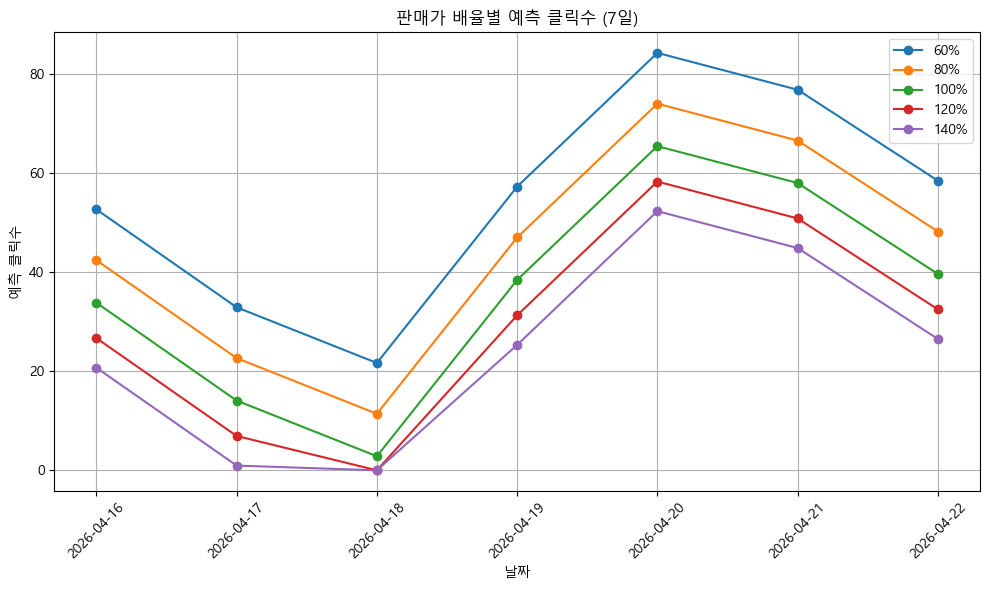

In [7]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 윈도우라면 보통 'Malgun Gothic' 사용
plt.rc('font', family='Malgun Gothic')

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False


plt.figure(figsize=(10,6))
for col in result_df.columns:
    plt.plot(result_df.index, result_df[col], marker='o', label=col)

plt.title("판매가 배율별 예측 클릭수 (7일)")
plt.xlabel("날짜")
plt.ylabel("예측 클릭수")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

mlp

In [ ]:
import datetime
import pandas as pd
import joblib
import torch
import torch.nn as nn

import sys, os

added_path = os.path.abspath("..")
sys.path.append(added_path)

# utils 모듈 임포트
from utils.naver_searchad_relkeyword import fetch_relkwdstat
from utils.naver_shoppinginsite_search import fetch_category_keyword_data

if added_path in sys.path:
    sys.path.remove(added_path)

# ===== 상수 선언 =====
KEYWORD = "참깨라면"
BASE_PRICE = 1000
PRICE_FACTORS = [0.6, 0.8, 1.0, 1.2, 1.4]
pum_id = "A01110"
CATEGORY_CODE = "50000006"

# ===== 모델 불러오기 =====
nn_package = joblib.load("../models/nn_model.pkl")
input_dim = nn_package["input_dim"]
columns = nn_package["columns"]
scaler = nn_package["scaler"]
pumid_encoder = nn_package["pumid_encoder"]   # 학습 때 저장한 인코더 불러오기

class SimpleMLPRegressor(nn.Module):
    def __init__(self, input_dim):
        super(SimpleMLPRegressor, self).__init__()
        self.fc1 = nn.Linear(input_dim, 32)
        self.fc2 = nn.Linear(32, 1)
        self.relu = nn.ReLU()
    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = SimpleMLPRegressor(input_dim=input_dim)
model.load_state_dict(nn_package["model_state"])
model.eval()

# ===== 예측 수행 =====
rows = []
dates = []

for day_offset in range(0, 7):
    target_date = datetime.date.today() + datetime.timedelta(days=day_offset)
    weekday = target_date.weekday()
    dates.append(target_date.strftime("%Y-%m-%d"))

    row = []
    for factor in PRICE_FACTORS:
        price = int(BASE_PRICE * factor)

        # pum_id 문자열을 인코더로 숫자 변환
        pum_id_enc = pumid_encoder.transform([pum_id])[0]

        test_data = {
            "1개당가격": price,
            "최근4주클릭수_비율": recent_ratio,
            "weekday": weekday,
            "pum_id_enc": pum_id_enc
        }
        test_df = pd.DataFrame([test_data])
        test_df = test_df.reindex(columns=columns, fill_value=0)

        # 스케일링
        X_scaled = scaler.transform(test_df)
        X_tensor = torch.tensor(X_scaled, dtype=torch.float32)

        with torch.no_grad():
            pred_clicks = model(X_tensor).cpu().numpy()[0][0]

        row.append(pred_clicks)
    rows.append(row)

# ===== 결과를 DataFrame으로 정리 =====
result_df = pd.DataFrame(rows, index=dates, columns=[f"{int(f*100)}%" for f in PRICE_FACTORS])
print(result_df)